In [ ]:
import glob
import random
import numpy as np
import matplotlib.pyplot as plt

# Use the time labels provided in your original dataset
time_labels = ['1 days', '2 days', '4 days', '7 days', '11 days', '17 days',
               '25 days', '37 days', '53 days', '77 days', '111 days', '158 days',
               '226 days', '323 days', '1.3 years', '1.8 years', '2.6 years',
               '3.6 years', '5.2 years', '7.3 years', '10.4 years', '14.8 years',
               '21.1 years', '30.0 years']

# Find all training files
all_files = sorted(glob.glob("dataset/train_data/*.npz"))
print(f"Found {len(all_files)} training files.")

# Global plotting settings
plt.rcParams["figure.figsize"] = (16, 8)

Found 4500 training files


In [ ]:
# Pick a sample to inspect
idx = 0 

with np.load(all_files[idx]) as data:
    porosity = data["porosity"]
    nz, nx = porosity.shape
    
    # 1. Recreate the combined source term
    perf_mask = np.zeros((nz, nx))
    z0, z1 = int(data["perf_interval"][0]), int(data["perf_interval"][1])
    # The well is at the first column (radius = 0)
    perf_mask[z0:z1+1, 0] = 1.0
    
    # Multiply the scalar rate by the location mask
    source_term = data["inj_rate"] * perf_mask

# Plot the source term and porosity side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

im0 = axes[0].imshow(porosity, origin="lower", aspect="auto", cmap="viridis")
axes[0].set_title("Porosity Field (Static)")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(source_term, origin="lower", aspect="auto", cmap="Reds")
axes[1].set_title("Combined Source Term (Rate * Location)")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

['porosity', 'perm_r', 'perm_z', 'inj_rate', 'temperature', 'depth', 'Swi', 'lam', 'perf_interval', 'pressure_buildup', 'gas_saturation']
Sample path: C:\Users\KirstyLocal\Projects\co2-plume-operator-learning\dataset\train_data\data_0003.npz
reservoir dimension is: (32, 200)
gas saturation dimension is: (32, 200, 24)
pressure buildup dimension is: (32, 200, 24)
inj_rate: 1.3823853637509944
temperature: 71.12895280122757
depth: 292.1177268028259
Swi: 0.15719308853149416
lam: 0.5664589405059814
perf_interval: [10 31]


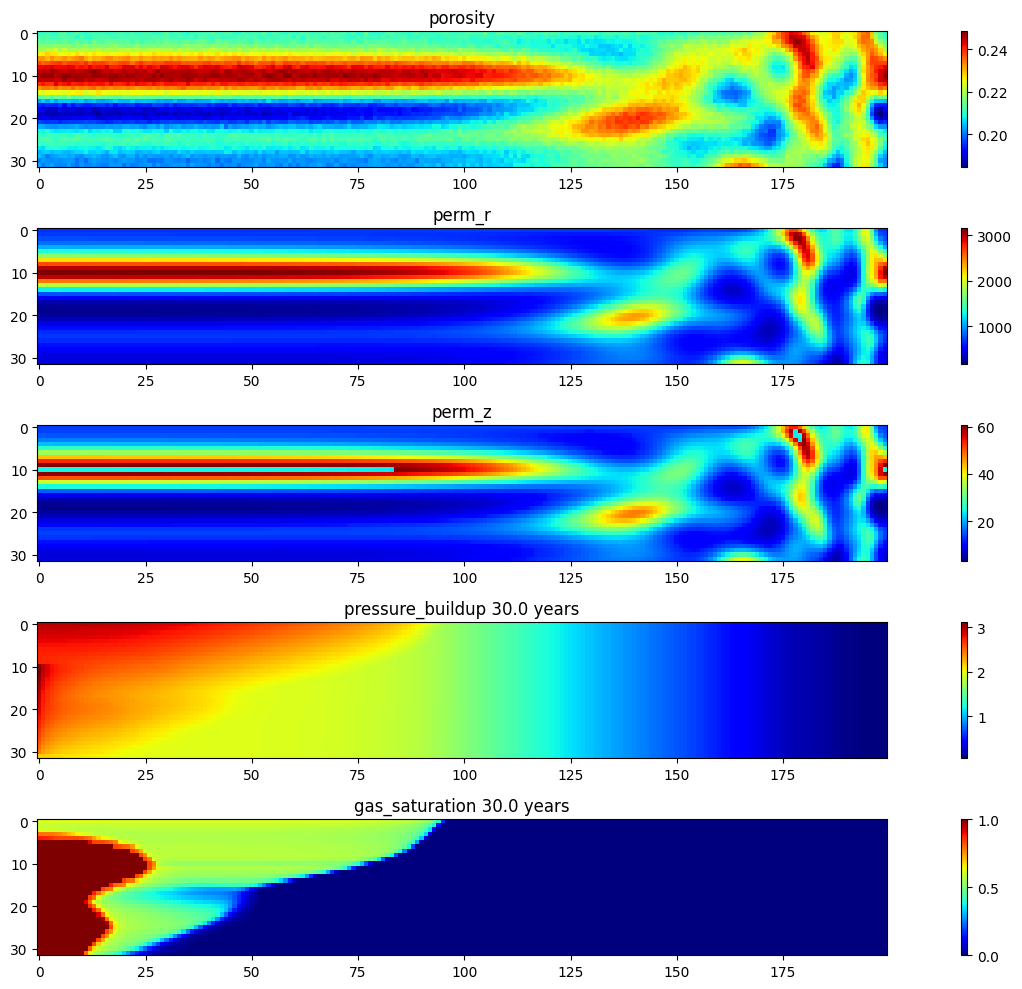

In [ ]:
with np.load(all_files[idx]) as data:
    gas = data["gas_saturation"] # Shape: (nz, nx, 24)

# Select indices for: Start, Early, Middle, and Final state
snapshot_indices = [0, 5, 15, 23] 

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, t in enumerate(snapshot_indices):
    im = axes[i].imshow(gas[:, :, t], origin="lower", aspect="auto", cmap="jet", vmin=0, vmax=1)
    axes[i].set_title(f"Gas Saturation\nTime: {time_labels[t]}")
    if i == 3: # Add colorbar to the last one
        plt.colorbar(im, ax=axes[i], label="Saturation")

plt.suptitle(f"Spatio-Temporal Evolution of CO2 Plume (Sample {idx})", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

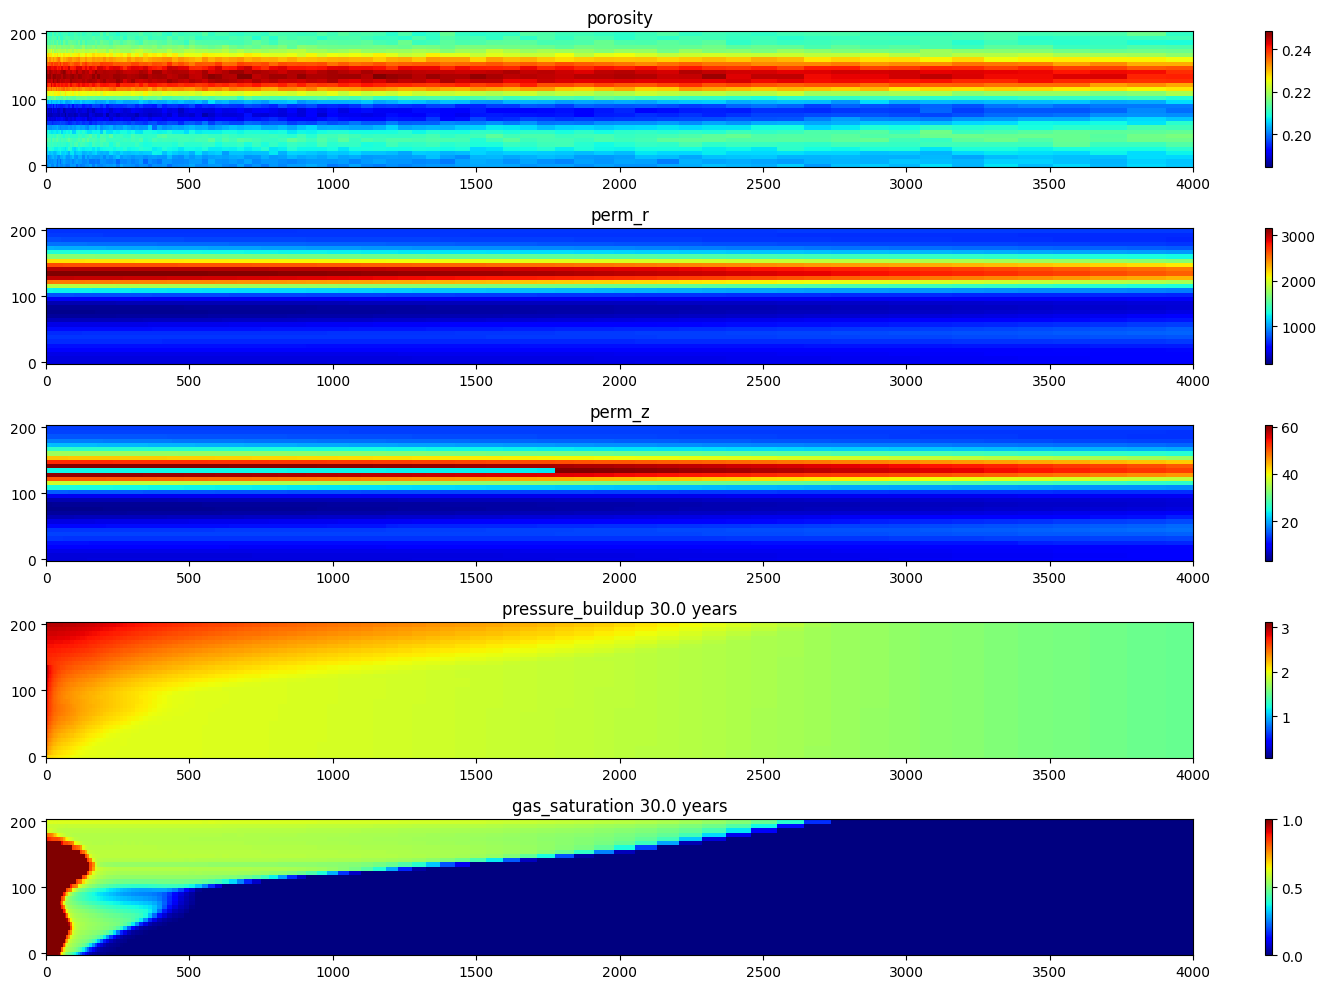

In [ ]:
with np.load(all_files[idx]) as data:
    pressure = data["pressure_buildup"] # Shape: (nz, nx, 24)

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, t in enumerate(snapshot_indices):
    im = axes[i].imshow(pressure[:, :, t], origin="lower", aspect="auto", cmap="magma")
    axes[i].set_title(f"Pressure Buildup\nTime: {time_labels[t]}")
    plt.colorbar(im, ax=axes[i])

plt.suptitle(f"Spatio-Temporal Pressure Distribution (Sample {idx})", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

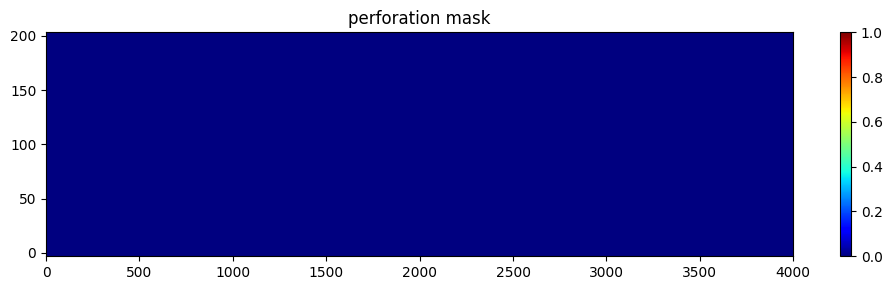

In [ ]:
# Build normalized coordinate channels matching model conventions
nt = 24
z_vals = np.linspace(-1.0, 1.0, nz, dtype=np.float32)
r_vals = np.linspace(-1.0, 1.0, nx, dtype=np.float32)
t_vals = np.linspace(0.0, 1.0, nt, dtype=np.float32)

Z_mesh = np.broadcast_to(z_vals[None, :, None], (nt, nz, nx))
R_mesh = np.broadcast_to(r_vals[None, None, :], (nt, nz, nx))
T_mesh = np.broadcast_to(t_vals[:, None, None], (nt, nz, nx))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# We look at a slice at t=0 to see spatial coordinates
axes[0].imshow(Z_mesh[0, :, :], origin="lower", aspect="auto")
axes[0].set_title("Z Coordinate Channel (Normalized)")

axes[1].imshow(R_mesh[0, :, :], origin="lower", aspect="auto")
axes[1].set_title("R Coordinate Channel (Normalized)")

# To see the Time channel, we look at a Z-R cross section over time
axes[2].plot(T_mesh[:, 0, 0])
axes[2].set_title("T Coordinate Channel (Normalized)")
axes[2].set_xlabel("Time Step Index")
axes[2].set_ylabel("Normalized Time Value")

plt.tight_layout()
plt.show()